### Setup

In [1]:
### Import packages ###
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
### Script definitions ###
BLOCK_SIZE = 10000 # Number of steps to keep from each training log file

# Define log directory
LOG_DIR = Path("/rds/general/user/ll1225/home/imperial_irp/extended_evo1")

# Define training log files
STAGE1_FILES = "training_metrics_20260820_132018.csv"

STAGE2_FILES_PARTIAL_DATA = [
    "training_metrics_20260820_174429.csv",
    "training_metrics_20260821_014814.csv",
    "training_metrics_20260821_103759.csv",
    "training_metrics_20260821_201555.csv",
    "training_metrics_20260822_104900.csv",
    "training_metrics_20260822_182652.csv",
    "training_metrics_20260823_011830.csv",
]

STAGE2_FILES_FULL_DATA = [
    "training_metrics_20260823_093847.csv",
    "training_metrics_20260823_184340.csv",
    "training_metrics_20260824_020209.csv",
    "training_metrics_20260824_090515.csv",
    "training_metrics_20260824_155614.csv",
    "training_metrics_20260824_230233.csv",
    "training_metrics_20260825_125037.csv",
    "training_metrics_20260825_204631.csv",
    "training_metrics_20260826_033130.csv",
    "training_metrics_20260826_103452.csv",
    "training_metrics_20260826_192904.csv",
    "training_metrics_20260827_021204.csv",
    "training_metrics_20260827_100005.csv",
    "training_metrics_20260827_174521.csv",
    "training_metrics_20260828_003323.csv",
    "training_metrics_20260828_092607.csv",
    "training_metrics_20260828_164012.csv",
    "training_metrics_20260829_003549.csv",
    "training_metrics_20260829_110736.csv",
    "training_metrics_20260829_175323.csv",
]

# Prepend LOG_DIR to every file
STAGE1_FILES = LOG_DIR / STAGE1_FILES
STAGE2_FILES_PARTIAL_DATA = [LOG_DIR / f for f in STAGE2_FILES_PARTIAL_DATA]
STAGE2_FILES_FULL_DATA = [LOG_DIR / f for f in STAGE2_FILES_FULL_DATA]

### Read files and extract relevant rows ###
# Define function for combining log files
def combine_log_files(files, block_size=10000):
    dfs = []

    for i, filename in enumerate(files):
        df = pd.read_csv(filename)

        # Range this file should contribute
        start = i * block_size
        end = start + block_size

        # Extract only that range
        df = df[
            (df["step"] >= start) &
            (df["step"] < end)
        ]

        dfs.append(df)

    # Combine in memory
    df = pd.concat(dfs, ignore_index=True)

    # Sort by step
    df = df.sort_values("step")

    return df

# Read all files, and extract only the rows in each log file corresponding to the number of steps defined in BLOCK_SIZE
# Initialise empty data frames for each training group
df_stage1 = []
df_stage2_partial = []
df_stage2_full = []

### Read CSV file to plot ###
df_stage1 = pd.read_csv(STAGE1_FILES) # Read STAGE 1 files
df_stage2_partial = combine_log_files(STAGE2_FILES_PARTIAL_DATA, BLOCK_SIZE) # Read STAGE 2 PARTIAL data files
df_stage2_full = combine_log_files(STAGE2_FILES_FULL_DATA, BLOCK_SIZE) # Read STAGE 2 FULL data files

### Plotting

#### Plot MSE Loss

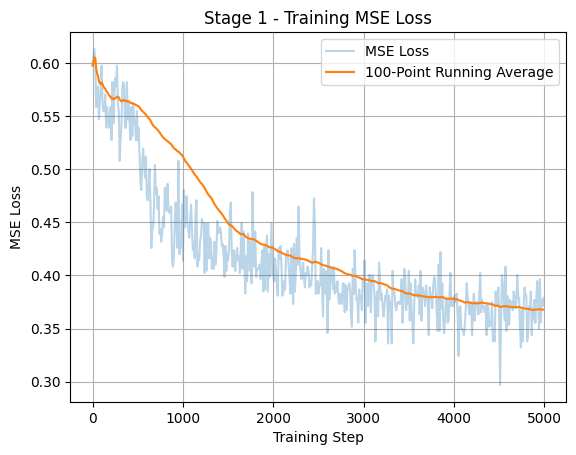

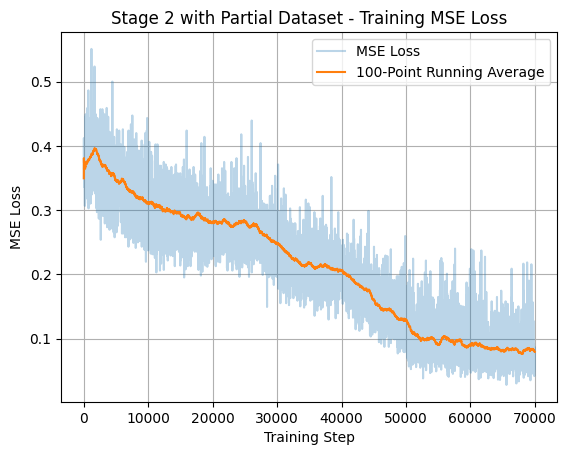

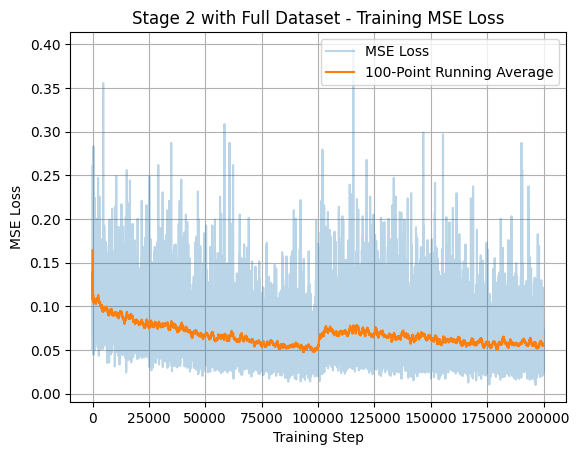

In [3]:
# # Create figure
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))#, sharey=True)

# # Plot stage 1 results
# axes[0].plot(
#     df_stage1["step"],
#     df_stage1["mse_loss"]
# )
# axes[0].set_xlabel("Training Step")
# axes[0].set_ylabel("MSE Loss")
# axes[0].set_title("Stage 1 Data")
# axes[0].grid(True)

# # Plot stage 2 partial data results
# axes[1].plot(
#     df_stage2_partial["step"],
#     df_stage2_partial["mse_loss"]
# )
# axes[1].set_xlabel("Training Step")
# axes[1].set_title("Stage 2 - Partial Data")
# axes[1].grid(True)

# # Plot stage 2 full data results
# axes[2].plot(
#     df_stage2_full["step"],
#     df_stage2_full["mse_loss"]
# )
# axes[2].set_xlabel("Training Step")
# axes[2].set_title("Stage 2 - Full Data")
# axes[2].grid(True)

# plt.tight_layout()
# plt.show()

### Define function for plotting the loss
def plot_loss(df, title, window=100):

    running_avg = df["mse_loss"].rolling(
        window=window,
        min_periods=1
    ).mean()

    plt.figure()

    plt.plot(
        df["step"],
        df["mse_loss"],
        alpha=0.3,
        label="MSE Loss"
    )

    plt.plot(
        df["step"],
        running_avg,
        label=f"{window}-Point Running Average"
    )

    plt.xlabel("Training Step")
    plt.ylabel("MSE Loss")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()

# Plot losses
plot_loss(df_stage1, "Stage 1 - Training MSE Loss")
plot_loss(df_stage2_partial, "Stage 2 with Partial Dataset - Training MSE Loss")
plot_loss(df_stage2_full, "Stage 2 with Full Dataset - Training MSE Loss")

#### Plot Per-dimension Loss

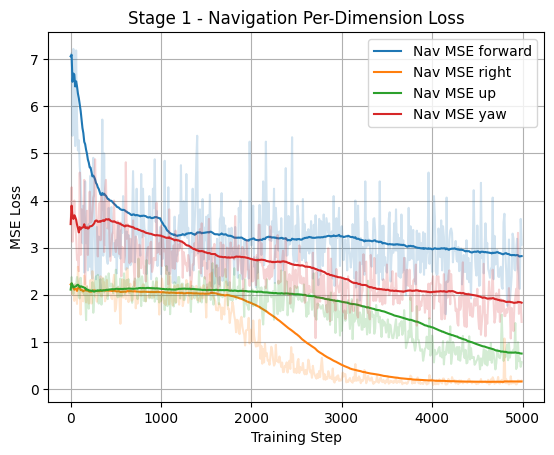

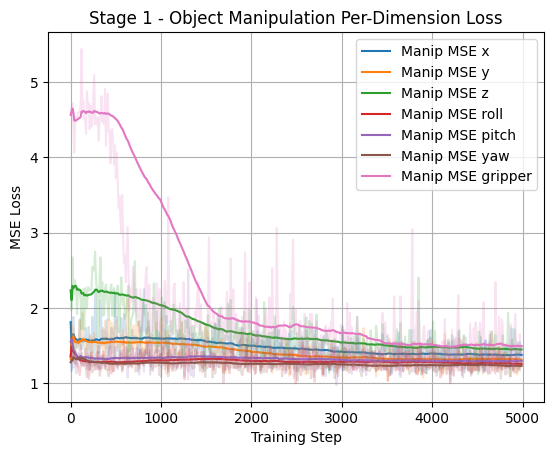

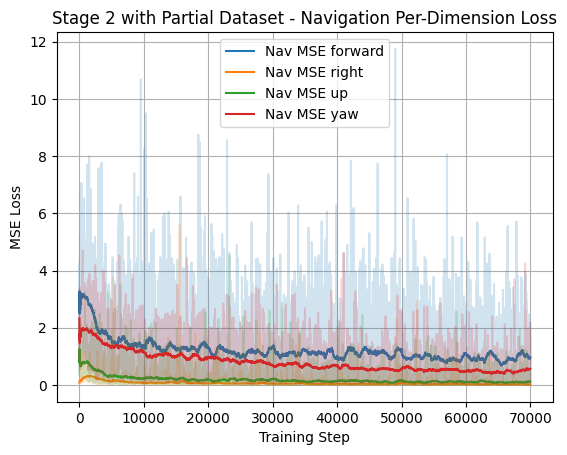

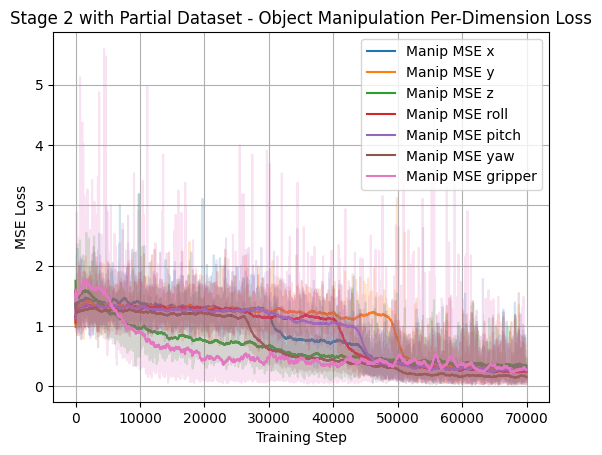

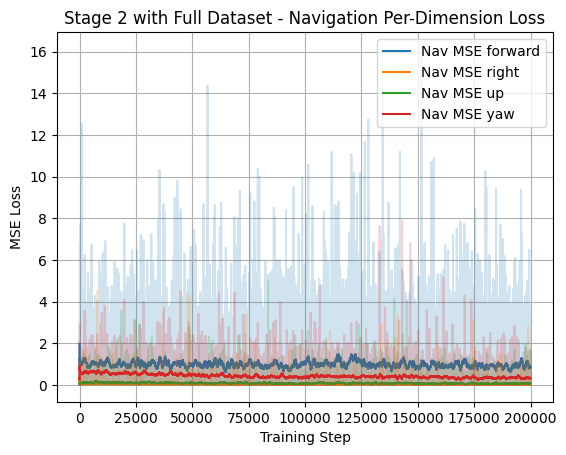

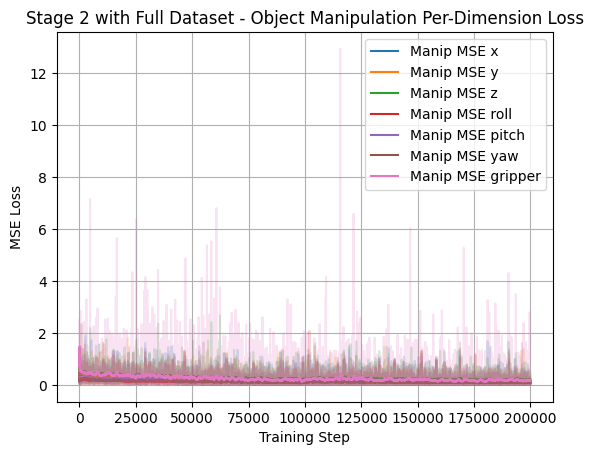

In [4]:
def plot_dimension_losses(df, dimensions, title, window=100):

    plt.figure()

    for column, label in dimensions:

        # Get the colour that will be used for this dimension
        color = plt.gca()._get_lines.get_next_color()

        # Raw loss
        plt.plot(
            df["step"],
            df[column],
            color=color,
            alpha=0.2
        )

        # Running average
        running_avg = df[column].rolling(
            window=window,
            min_periods=1
        ).mean()

        plt.plot(
            df["step"],
            running_avg,
            color=color,
            label=label
        )

    plt.xlabel("Training Step")
    plt.ylabel("MSE Loss")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()

### Define dimensions ###
nav_dimensions = [
    ("nav_mse_x", "Nav MSE forward"),
    ("nav_mse_y", "Nav MSE right"),
    ("nav_mse_z", "Nav MSE up"),
    ("nav_mse_angle3", "Nav MSE yaw"),
]

manip_dimensions = [
    ("manip_mse_x", "Manip MSE x"),
    ("manip_mse_y", "Manip MSE y"),
    ("manip_mse_z", "Manip MSE z"),
    ("manip_mse_angle1", "Manip MSE roll"),
    ("manip_mse_angle2", "Manip MSE pitch"),
    ("manip_mse_angle3", "Manip MSE yaw"),
    ("manip_mse_gripper", "Manip MSE gripper"),
]

### Plot ###
# Plot for stage 1
plot_dimension_losses(
    df_stage1,
    nav_dimensions,
    "Stage 1 - Navigation Per-Dimension Loss"
)

plot_dimension_losses(
    df_stage1,
    manip_dimensions,
    "Stage 1 - Object Manipulation Per-Dimension Loss"
)

# Plot for stage 2 partial data
plot_dimension_losses(
    df_stage2_partial,
    nav_dimensions,
    "Stage 2 with Partial Dataset - Navigation Per-Dimension Loss"
)

plot_dimension_losses(
    df_stage2_partial,
    manip_dimensions,
    "Stage 2 with Partial Dataset - Object Manipulation Per-Dimension Loss"
)

# Plot for stage 2 full data
plot_dimension_losses(
    df_stage2_full,
    nav_dimensions,
    "Stage 2 with Full Dataset - Navigation Per-Dimension Loss"
)

plot_dimension_losses(
    df_stage2_full,
    manip_dimensions,
    "Stage 2 with Full Dataset - Object Manipulation Per-Dimension Loss"
)

#### Plot Navigation and Manipulation Loss

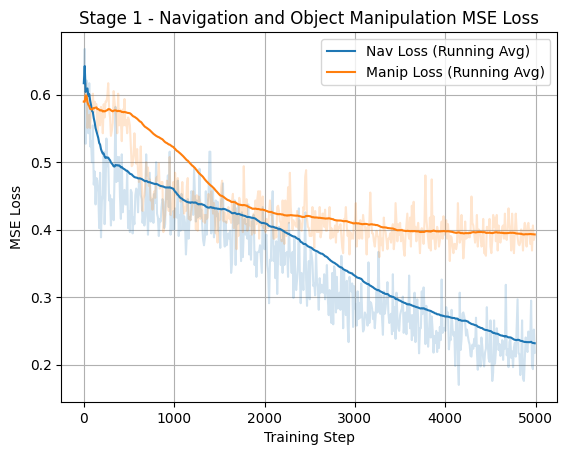

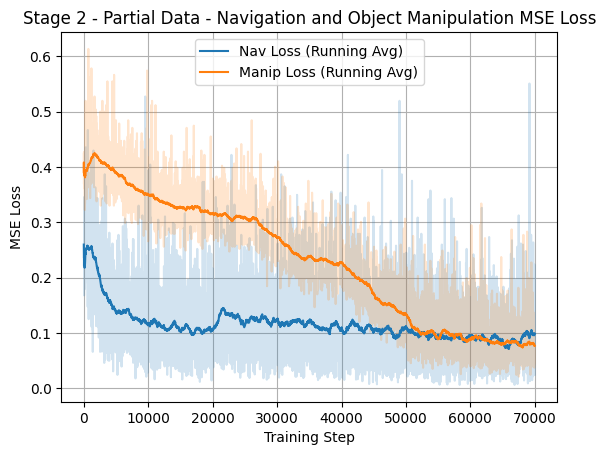

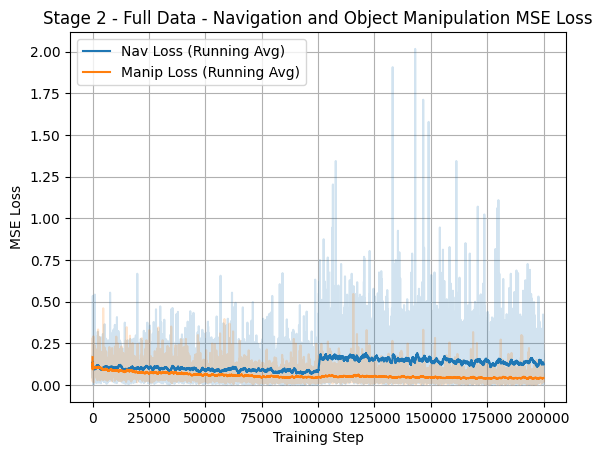

In [7]:
def plot_nav_manip_loss(df, title, window=100):

    nav_avg = df["nav_loss"].rolling(
        window=window,
        min_periods=1
    ).mean()

    manip_avg = df["manip_loss"].rolling(
        window=window,
        min_periods=1
    ).mean()

    plt.figure()

    # Get two colours from Matplotlib's colour cycle
    nav_color = plt.gca()._get_lines.get_next_color()
    manip_color = plt.gca()._get_lines.get_next_color()

    # Raw losses
    plt.plot(
        df["step"],
        df["nav_loss"],
        color=nav_color,
        alpha=0.2
    )

    plt.plot(
        df["step"],
        df["manip_loss"],
        color=manip_color,
        alpha=0.2
    )

    # Running averages
    plt.plot(
        df["step"],
        nav_avg,
        color=nav_color,
        label="Nav Loss (Running Avg)"
    )

    plt.plot(
        df["step"],
        manip_avg,
        color=manip_color,
        label="Manip Loss (Running Avg)"
    )

    plt.xlabel("Training Step")
    plt.ylabel("MSE Loss")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()


### Plot ###
plot_nav_manip_loss(
    df_stage1,
    "Stage 1 - Navigation and Object Manipulation MSE Loss"
)

plot_nav_manip_loss(
    df_stage2_partial,
    "Stage 2 - Partial Data - Navigation and Object Manipulation MSE Loss"
)

plot_nav_manip_loss(
    df_stage2_full,
    "Stage 2 - Full Data - Navigation and Object Manipulation MSE Loss"
)

#### Get Batch Sampling Statistics

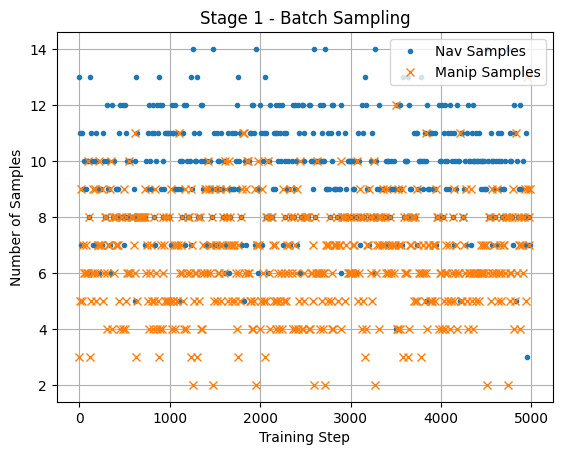


Stage 1 - Batch Sampling

Navigation samples per batch:
nav_samples
3       1
4       1
5       7
6      16
7      41
8      89
9      89
10    107
11     76
12     53
13     12
14      8
Name: count, dtype: int64

Manipulation samples per batch:
manip_samples
2       8
3      12
4      53
5      76
6     107
7      89
8      89
9      41
10     16
11      7
12      1
13      1
Name: count, dtype: int64


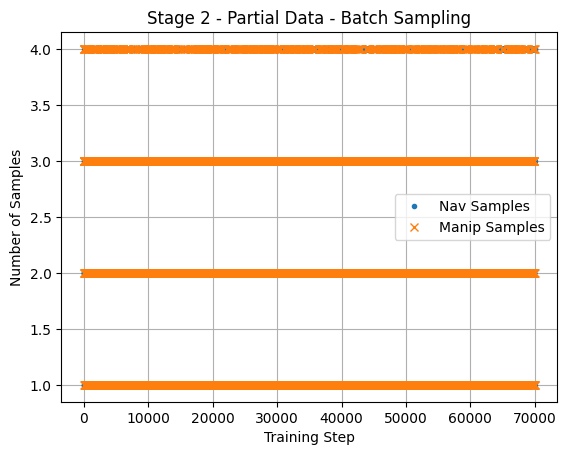


Stage 2 - Partial Data - Batch Sampling

Navigation samples per batch:
nav_samples
1     598
2    1798
3    2666
4    1938
Name: count, dtype: int64

Manipulation samples per batch:
manip_samples
1    1938
2    2666
3    1798
4     598
Name: count, dtype: int64


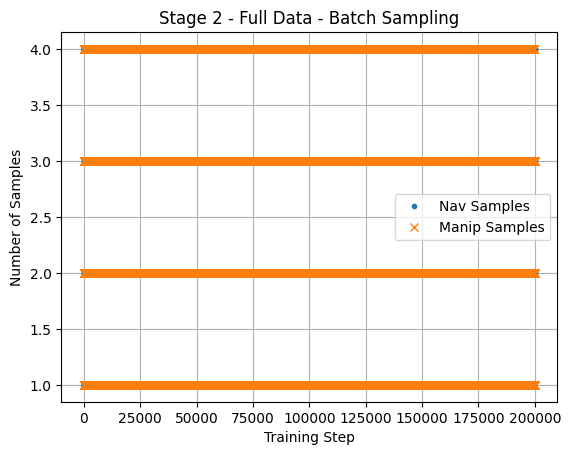


Stage 2 - Full Data - Batch Sampling

Navigation samples per batch:
nav_samples
1    2021
2    5535
3    7414
4    5030
Name: count, dtype: int64

Manipulation samples per batch:
manip_samples
1    5030
2    7414
3    5535
4    2021
Name: count, dtype: int64


In [24]:
def analyse_sampling(df, title):
    
    # Plot sampling
    plt.figure()

    plt.plot(
        df["step"],
        df["nav_samples"],
        '.',
        label="Nav Samples"
    )

    plt.plot(
        df["step"],
        df["manip_samples"],
        'x',
        label="Manip Samples"
    )

    plt.xlabel("Training Step")
    plt.ylabel("Number of Samples")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()

    # Print sampling distributions
    print(f"\n{title}")
    print("=" * len(title))

    print("\nNavigation samples per batch:")
    print(df["nav_samples"].value_counts().sort_index())

    print("\nManipulation samples per batch:")
    print(df["manip_samples"].value_counts().sort_index())

### Get statistics ###
analyse_sampling(
    df_stage1,
    "Stage 1 - Batch Sampling"
)

analyse_sampling(
    df_stage2_partial,
    "Stage 2 - Partial Data - Batch Sampling"
)

analyse_sampling(
    df_stage2_full,
    "Stage 2 - Full Data - Batch Sampling"
)

#### Plot Cosine Similarity


Stage 1 - Gradient Cosine Similarity
Total values:       500
Positive (> 0.01):  0 (0.00%)
Negative (< -0.01): 0 (0.00%)
Near zero:          500 (100.00%)


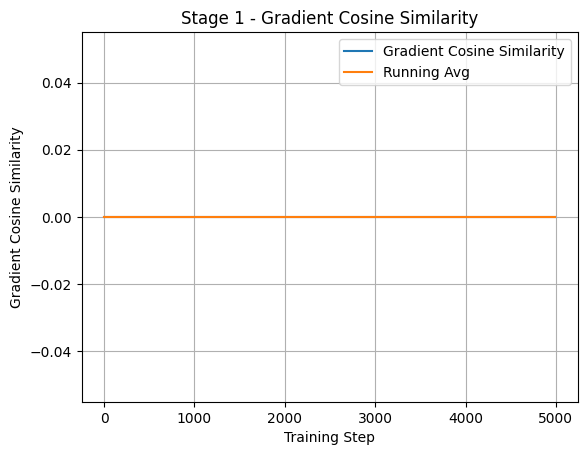


Stage 2 with Partial Dataset - Gradient Cosine Similarity
Total values:       7000
Positive (> 0.01):  1178 (16.83%)
Negative (< -0.01): 1190 (17.00%)
Near zero:          4632 (66.17%)


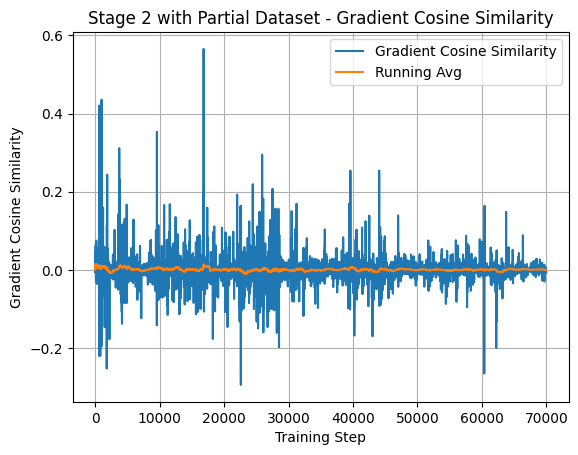


Stage 2 with Full Dataset - Gradient Cosine Similarity
Total values:       20000
Positive (> 0.01):  828 (4.14%)
Negative (< -0.01): 868 (4.34%)
Near zero:          18304 (91.52%)


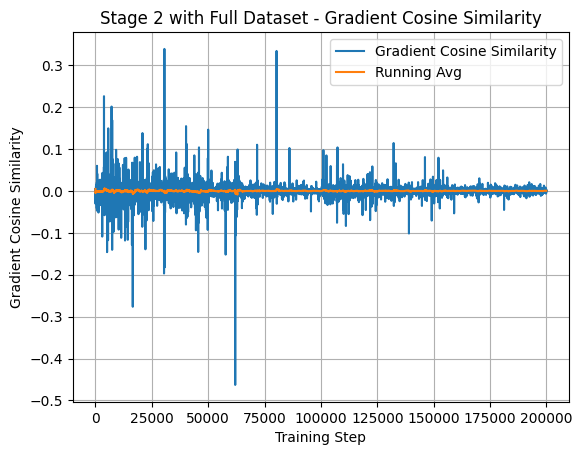

In [48]:
# def plot_cosine_similarity(df, title, window=100):

#     cosine = df["grad_cosine_similarity"]

#     # Count positive, negative, and zero values
#     positive = (cosine > 0).sum()
#     negative = (cosine < 0).sum()
#     zero = (cosine == 0).sum()

#     total = len(cosine)

#     print(f"\n{title}")
#     print("=" * len(title))
#     print(f"Total values:     {total}")
#     print(f"Positive (> 0):   {positive} ({positive / total * 100:.2f}%)")
#     print(f"Negative (< 0):   {negative} ({negative / total * 100:.2f}%)")
#     print(f"Zero (= 0):       {zero} ({zero / total * 100:.2f}%)")

#     # Running average
#     running_avg = cosine.rolling(
#         window=window,
#         min_periods=1
#     ).mean()

#     plt.figure()

#     # Raw cosine similarity
#     plt.plot(
#         df["step"],
#         cosine,
#     )

#     # Running average
#     plt.plot(
#         df["step"],
#         running_avg,
#         label="Gradient Cosine Similarity"
#     )

#     plt.xlabel("Training Step")
#     plt.ylabel("Grad Cosine Similarity")
#     plt.title(title)

#     plt.legend()
#     plt.grid(True)

#     plt.show()

def plot_cosine_similarity(df, title, window=100, threshold=0.01):

    cosine = df["grad_cosine_similarity"]

    # Count values using threshold
    positive = (cosine > threshold).sum()
    negative = (cosine < -threshold).sum()
    zero = ((cosine >= -threshold) & (cosine <= threshold)).sum()

    total = len(cosine)

    print(f"\n{title}")
    print("=" * len(title))
    print(f"Total values:       {total}")
    print(f"Positive (> {threshold}):  {positive} ({positive / total * 100:.2f}%)")
    print(f"Negative (< -{threshold}): {negative} ({negative / total * 100:.2f}%)")
    print(f"Near zero:          {zero} ({zero / total * 100:.2f}%)")

    # Running average
    running_avg = cosine.rolling(
        window=window,
        min_periods=1
    ).mean()

    # Plot — unchanged
    plt.figure()

    plt.plot(
        df["step"],
        cosine,
        label="Gradient Cosine Similarity"
    )

    plt.plot(
        df["step"],
        running_avg,
        label="Running Avg"
    )

    plt.xlabel("Training Step")
    plt.ylabel("Gradient Cosine Similarity")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()

### Plot ###
plot_cosine_similarity(
    df_stage1,
    "Stage 1 - Gradient Cosine Similarity"
)

plot_cosine_similarity(
    df_stage2_partial,
    "Stage 2 with Partial Dataset - Gradient Cosine Similarity"
)

plot_cosine_similarity(
    df_stage2_full,
    "Stage 2 with Full Dataset - Gradient Cosine Similarity"
)